In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import fsolve

## Question 1 ##

In [2]:
# Paramètres
S_0 = 10e6
I_0 = 10
R_0 = 0
r = 0.5
a = 0.33
T = 150.0
N = 150
h = T / N

In [3]:
# Fonction pour le modèle SIR
def sir_model(y, t, r, a):
    S, I, R = y
    dSdt = -r * S * I
    dIdt = r * S * I - a * I
    dRdt = a * I
    return [dSdt, dIdt, dRdt]

t = np.linspace(0,T,N+1)
N_pop = S_0+I_0+R_0
y_0 = [S_0/N_pop, I_0/N_pop, R_0/N_pop]
sol_exact = odeint(sir_model, y_0, t, args = (r,a))

S, I, R = sol_exact.T

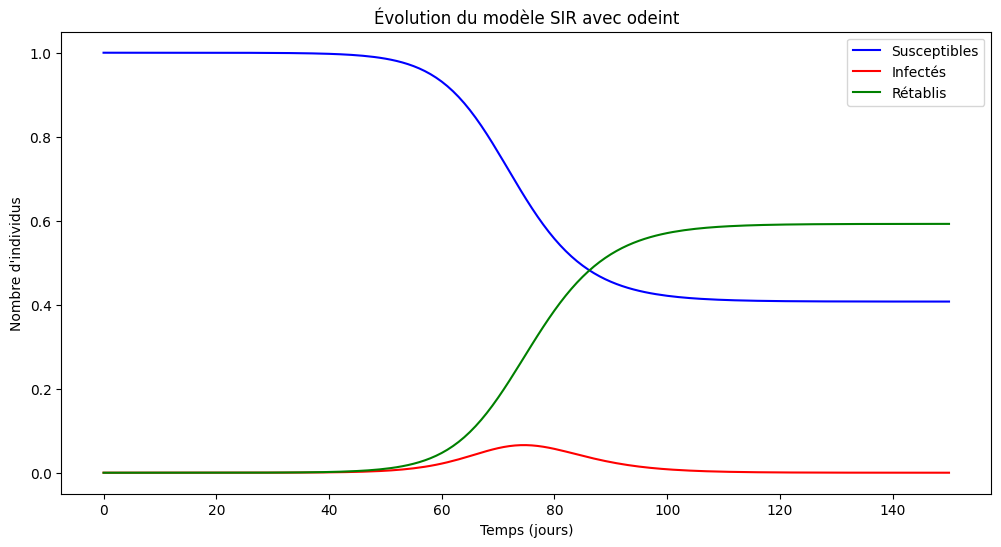

In [4]:
# Tracé des résultats
plt.figure(figsize=(12, 6))
plt.plot(t, S, label='Susceptibles', color='blue')
plt.plot(t, I, label='Infectés', color='red')
plt.plot(t, R, label='Rétablis', color='green')
plt.xlabel('Temps (jours)')
plt.ylabel('Nombre d\'individus')
plt.legend()
plt.title('Évolution du modèle SIR avec odeint')
plt.show()

## Question 2 ##

In [5]:
T_0 = 52.
T = 60.

# Fonction pour le schéma d'Euler explicite
def euler_explicite(y_init, t,h):
    n = len(t)
    d = len(y_init)
    y = np.zeros((n, d))
    y[0] = y_init

    for i in range(1, n):
        y[i] = y[i-1] + h * np.array(sir_model(y[i-1], t[i-1], r, a))

    return y

[np.float64(3.157882182488765e-09), np.float64(7.829491712082651e-08), np.float64(3.099611958378231e-07), np.float64(7.141412168738293e-06), np.float64(2.586057936463442e-05), np.float64(8.55612531971152e-05), np.float64(0.00024289059954754667)]


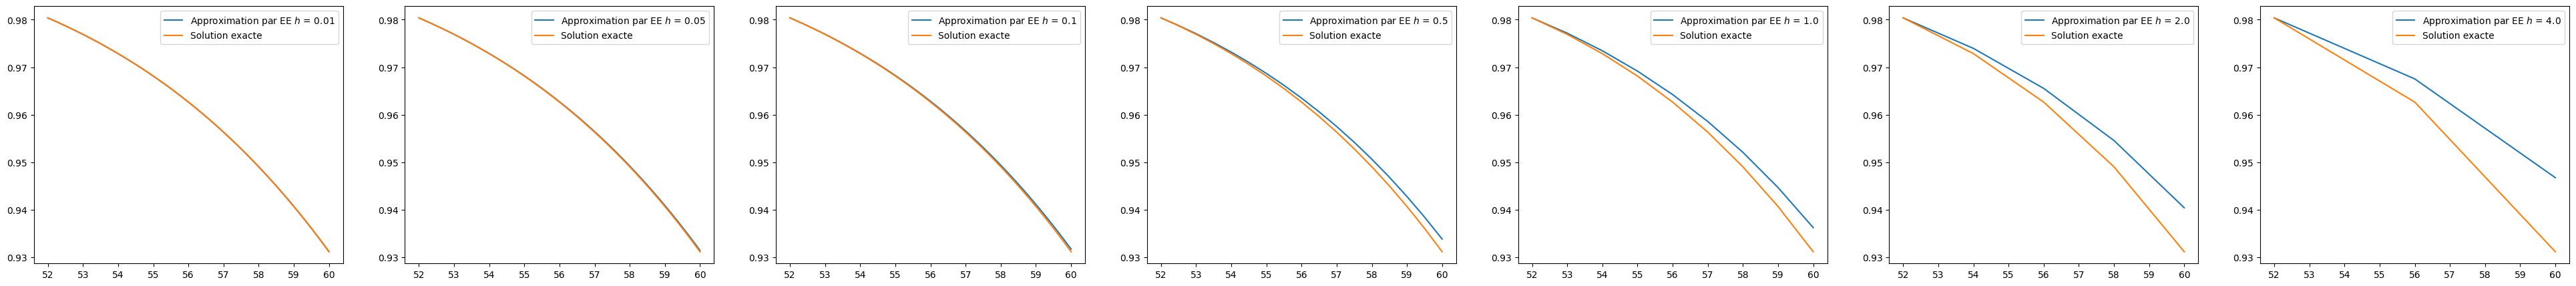

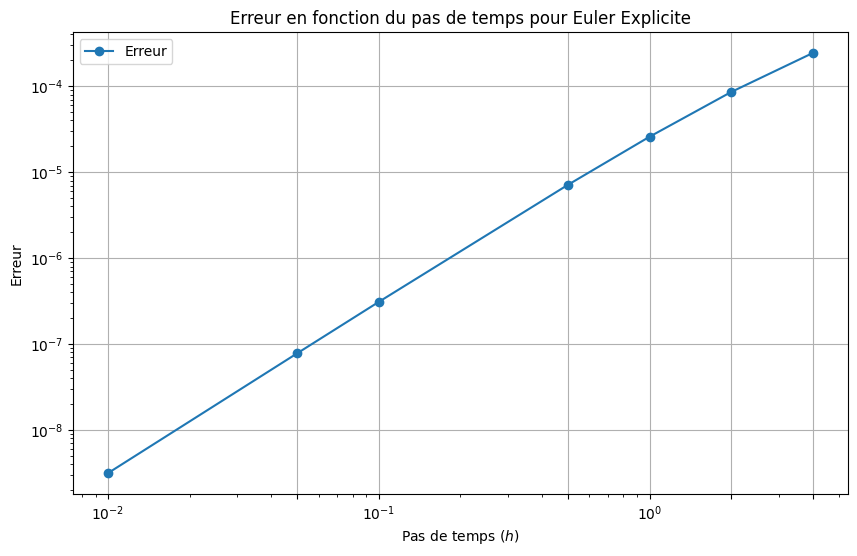

In [17]:
# Calcul des solutions avec différents pas de temps
h_values = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 4.0]
errors_EE = []

y_init = np.array([S[int(T_0)], I[int(T_0)], R[int(T_0)]])

fig, axes = plt.subplots(1, len(h_values), figsize=(len(h_values)*7, 5))

for _,h in enumerate(h_values):
    ax=axes[_]
    #print(f"h = {h}")
    N = int((T-T_0)/h)
    t_array = np.linspace(T_0, T, N+1)
    sol_euler = euler_explicite(y_init, t_array, h)
    sol_exact_ = odeint(sir_model, y_init, t_array, args=(r, a))
    error = np.max(np.abs(sol_euler - sol_exact_)**2)
    errors_EE.append(error)

    ax.plot(t_array, sol_euler[:,0], label = rf'Approximation par EE $h$ = {h}')
    ax.plot(t_array, sol_exact_[:,0], label = 'Solution exacte')
    ax.legend()

print(errors_EE)

# Tracé de l'erreur en fonction du pas de temps
plt.figure(figsize=(10, 6))
plt.loglog(h_values, errors_EE, marker='o', linestyle='-', label = "Erreur")
plt.xlabel(r'Pas de temps ($h$)')
plt.xticks(h_values)
plt.ylabel('Erreur')
plt.title('Erreur en fonction du pas de temps pour Euler Explicite')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
def euler_implicite(y_0, t, h):
    n = len(t)
    d = len(y_0)
    y = np.zeros((n, d))
    y[0] = y_0
    for i in range(1, n):
        y[i] = fsolve(lambda y_next: y_next - y[i-1] - h * np.array(sir_model(y_next, t[i], r, a)), y[i-1])
    return y

Erreurs : [2.6674090849498496e-05, 0.00013429496113906577, 0.0002706558209999885, 0.0014384016216842897, 0.0031077615665659514, 0.007267427992574851, 0.01952566388308462]


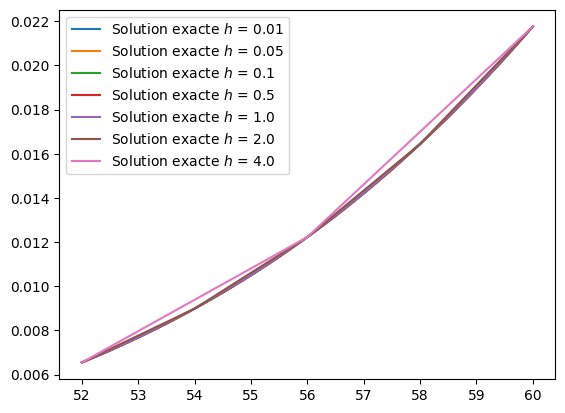

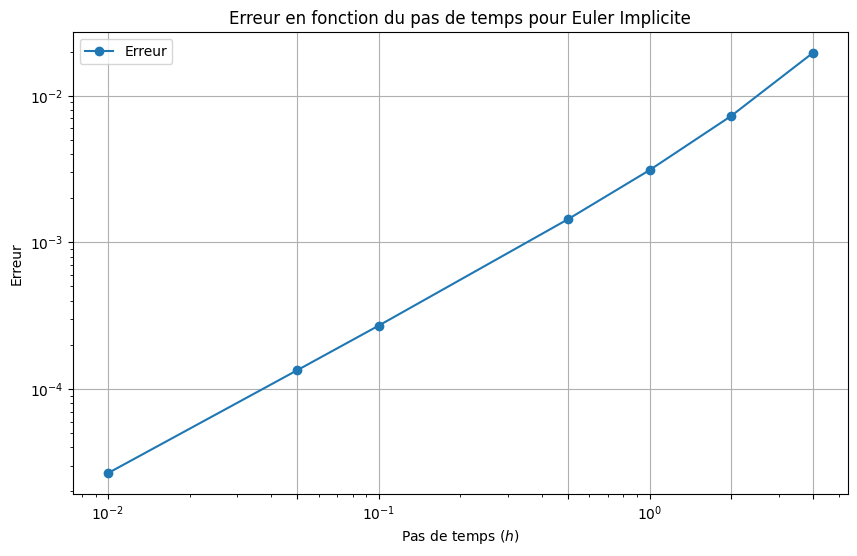

In [20]:
# Calcul de la solution de référence avec odeint pour un pas de temps très fin
N = int((T-T_0)/h)
t_fine = np.linspace(T_0, T, N+1)
sol_exact_fine = odeint(sir_model, y_init, t_fine, args=(r, a))

# Calcul des solutions avec différents pas de temps
errors_EI = []

for h in h_values:

    N = int((T-T_0)/h)
    t_array = np.linspace(T_0, T, N+1)
    sol_euler = euler_implicite(y_init, t_array, h)
    sol_exact_ = odeint(sir_model, y_init, t_array, args=(r, a))
    error = np.mean(np.linalg.norm(sol_euler - sol_exact_, axis=1))
    #print(np.linalg.norm(sol_euler - sol_exact_, axis=1))
    errors_EI.append(error)

    # plt.plot(t_array, sol_euler[:,1], label = 'Approximation par EE')
    plt.plot(t_array, sol_exact_[:,1], label = rf'Solution exacte $h$ = {h}')
    plt.legend()


errors = [float(error) for error in errors_EI]
print(f"Erreurs : {errors}")

# Tracé de l'erreur en fonction du pas de temps
plt.figure(figsize=(10, 6))
plt.loglog(h_values, errors, marker='o', linestyle='-', label = 'Erreur')
plt.xlabel(r'Pas de temps ($h$)')
plt.xticks(h_values)
plt.ylabel('Erreur')
plt.title('Erreur en fonction du pas de temps pour Euler Implicite')
plt.grid(True)
plt.legend()
plt.show()

In [9]:
def heun(y_init, t, h):
    n = len(t)
    d = len(y_init)
    y = np.zeros((n, d))
    y[0] = y_init

    for i in range(1, n):
        k1 = np.array(sir_model(y[i-1], t[i-1], r, a))
        k2 = np.array(sir_model(y[i-1] + h * k1, t[i], r, a))
        y[i] = y[i-1] + (h/2) * (k1 + k2)

    return y

Erreurs : [2.6674090849498496e-05, 0.00013429496113906577, 0.0002706558209999885, 0.0014384016216842897, 0.0031077615665659514, 0.007267427992574851, 0.01952566388308462]


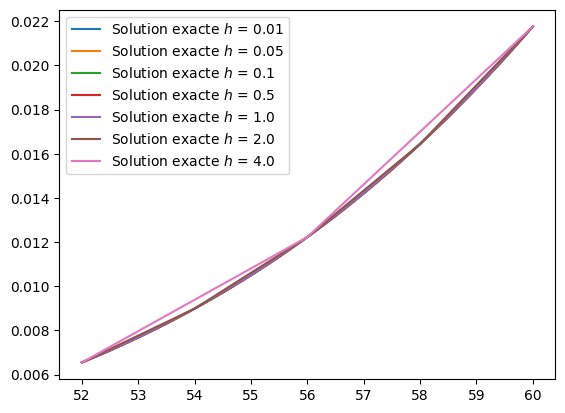

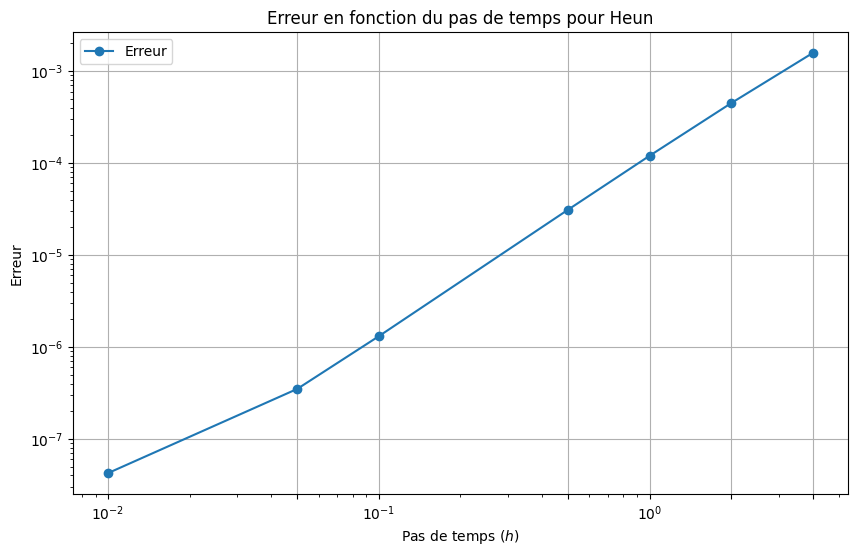

In [22]:
# Calcul de la solution de référence avec odeint pour un pas de temps très fin
N = int((T-T_0)/h)
t_fine = np.linspace(T_0, T, N+1)
sol_exact_fine = odeint(sir_model, y_init, t_fine, args=(r, a))

# Calcul des solutions avec différents pas de temps
errors_H = []

for h in h_values:

    N = int((T-T_0)/h)
    t_array = np.linspace(T_0, T, N+1)
    sol_euler = heun(y_init, t_array, h)
    sol_exact_ = odeint(sir_model, y_init, t_array, args=(r, a))
    error = np.mean(np.linalg.norm(sol_euler - sol_exact_, axis=1))
    #print(np.linalg.norm(sol_euler - sol_exact_, axis=1))
    errors_H.append(error)

    # plt.plot(t_array, sol_euler[:,1], label = 'Approximation par EE')
    plt.plot(t_array, sol_exact_[:,1], label = rf'Solution exacte $h$ = {h}')
    plt.legend()


errors_H = [float(error) for error in errors_H]
print(f"Erreurs : {errors}")

# Tracé de l'erreur en fonction du pas de temps
plt.figure(figsize=(10, 6))
plt.loglog(h_values, errors_H, marker='o', linestyle='-', label = 'Erreur')
plt.xlabel(r'Pas de temps ($h$)')
plt.xticks(h_values)
plt.ylabel('Erreur')
plt.title('Erreur en fonction du pas de temps pour Heun')
plt.grid(True)
plt.legend()
plt.show()

### RK4 méthode

In [11]:
def rk4(y_init, t, h):
    n = len(t)
    d = len(y_init)
    y = np.zeros((n, d))
    y[0] = y_init

    for i in range(1, n):
        k1 = np.array(sir_model(y[i-1], t[i-1], r, a))
        k2 = np.array(sir_model(y[i-1] + (h/2) * k1, t[i-1] + h/2, r, a))
        k3 = np.array(sir_model(y[i-1] + (h/2) * k2, t[i-1] + h/2, r, a))
        k4 = np.array(sir_model(y[i-1] + h * k3, t[i], r, a))
        y[i] = y[i-1] + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

    return y

Erreurs : [2.6674090849498496e-05, 0.00013429496113906577, 0.0002706558209999885, 0.0014384016216842897, 0.0031077615665659514, 0.007267427992574851, 0.01952566388308462]


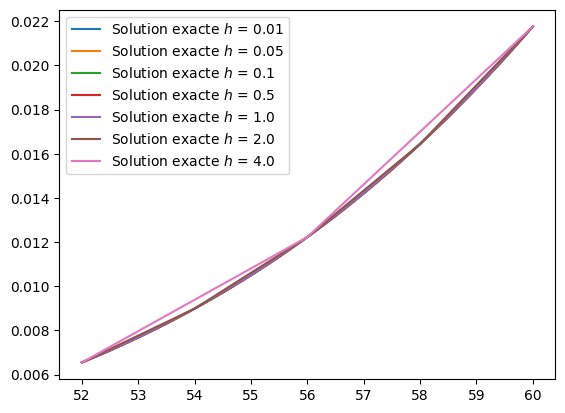

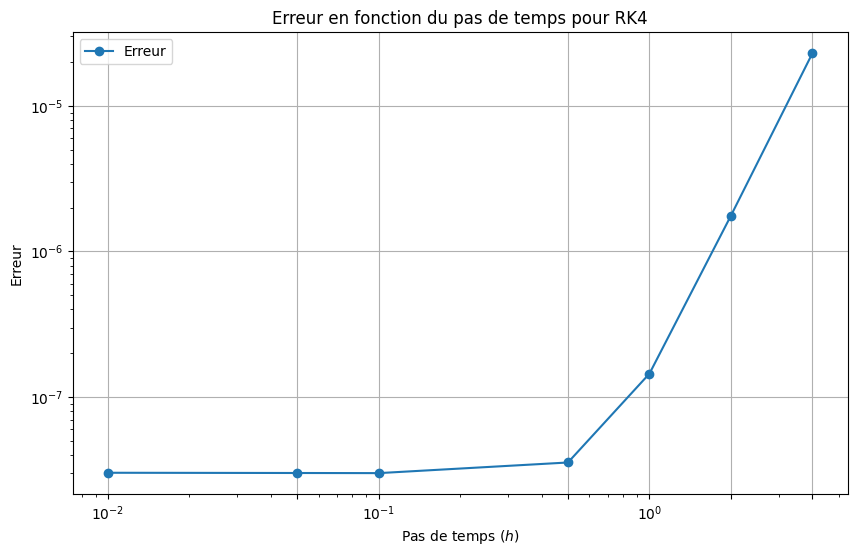

In [24]:
# Calcul de la solution de référence avec odeint pour un pas de temps très fin
N = int((T-T_0)/h)
t_fine = np.linspace(T_0, T, N+1)
sol_exact_fine = odeint(sir_model, y_init, t_fine, args=(r, a))

# Calcul des solutions avec différents pas de temps
errors_RK4 = []

for h in h_values:

    N = int((T-T_0)/h)
    t_array = np.linspace(T_0, T, N+1)
    sol_RK4 = rk4(y_init, t_array, h)
    sol_exact_ = odeint(sir_model, y_init, t_array, args=(r, a))
    error = np.mean(np.linalg.norm(sol_RK4 - sol_exact_, axis=1))

    errors_RK4.append(error)

    # plt.plot(t_array, sol_RK4[:,1], label = 'Approximation par EE')
    plt.plot(t_array, sol_exact_[:,1], label = rf'Solution exacte $h$ = {h}')
    plt.legend()


errors_RK4 = [float(error) for error in errors_RK4]
print(f"Erreurs : {errors}")

# Tracé de l'erreur en fonction du pas de temps
plt.figure(figsize=(10, 6))
plt.loglog(h_values, errors_RK4, marker='o', linestyle='-', label = 'Erreur')
plt.xlabel(r'Pas de temps ($h$)')
plt.xticks(h_values)
plt.ylabel('Erreur')
plt.title('Erreur en fonction du pas de temps pour RK4')
plt.grid(True)
plt.legend()
plt.show()

## Comparaison des erreurs

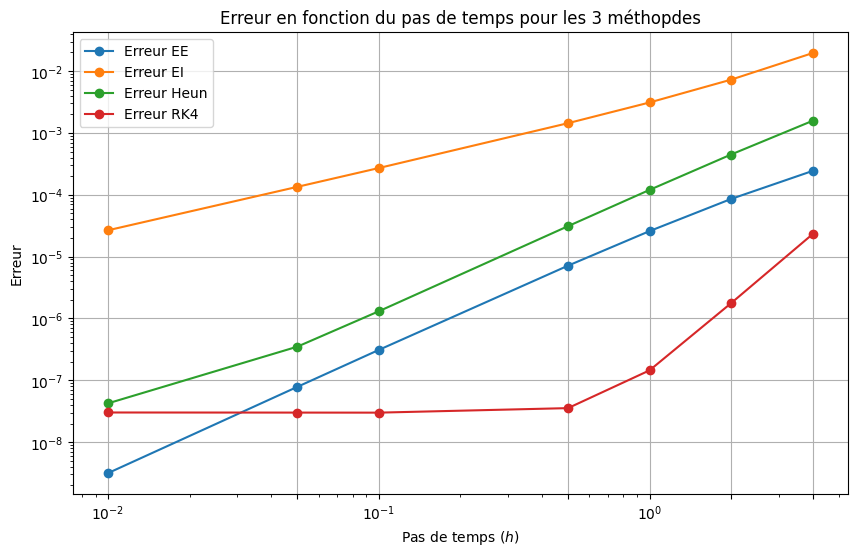

In [25]:
plt.figure(figsize=(10, 6))
plt.loglog(h_values, errors_EE, marker='o', linestyle='-', label = 'Erreur EE')
plt.loglog(h_values, errors_EI, marker='o', linestyle='-', label = 'Erreur EI')
plt.loglog(h_values, errors_H, marker='o', linestyle='-', label = 'Erreur Heun')
plt.loglog(h_values, errors_RK4, marker='o', linestyle='-', label = 'Erreur RK4')
plt.xlabel(r'Pas de temps ($h$)')
plt.xticks(h_values)
plt.ylabel('Erreur')
plt.title('Erreur en fonction du pas de temps pour les 3 méthopdes')
plt.grid(True)
plt.legend()
plt.show()

## Question 3 ##

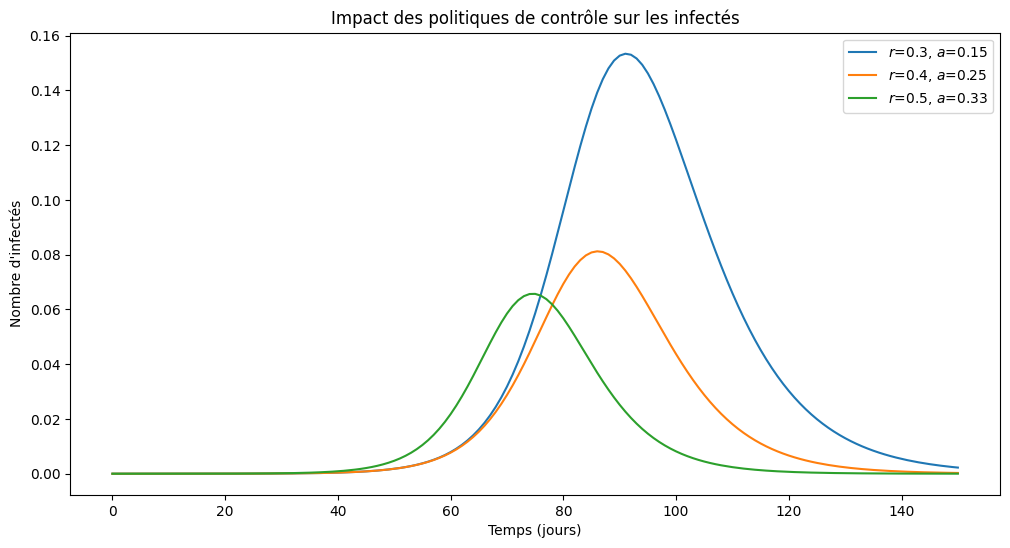

In [26]:
# Question 3
# Étudier l'impact des politiques de contrôle (changer r et a)

# Exemple de changement de r et a
r_values = [0.3, 0.4, 0.5]
a_values = [0.15, 0.25, 0.33]

plt.figure(figsize=(12, 6))
for r_val, a_val in zip(r_values, a_values):
    sol = odeint(sir_model, y_0, t, args=(r_val, a_val))
    S, I, R = sol.T
    plt.plot(t, I, label=rf'$r$={r_val}, $a$={a_val}')

plt.xlabel('Temps (jours)')
plt.ylabel('Nombre d\'infectés')
plt.legend()
plt.title('Impact des politiques de contrôle sur les infectés')
plt.show()
